# Washington — Adverse Events EDA
**Source:** WA Dept of Health — Downloadable Adverse Events file (2026-04-07)
**Dataset:** Adverse event reporting by facility × event type × year (2014–2025)
**Rows:** ~188,160 | **Facility types:** ASF, Acute Care Hospitals, Birthing Centers, Psychiatric…

This notebook explores Washington State's mandatory adverse event reporting under RCW 70.56.
Most rows have **zero** reported events; analysis focuses on non-zero events.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
FILE = '../../data/source/Washington/WA-downloadable_ae - 2026-04-07.csv'
wa = pd.read_csv(FILE)

# Drop pre-computed percentage column — all analysis uses raw counts
wa = wa.drop(columns=['Percentage of Adverse Events'], errors='ignore')

print(f'Full dataset — Rows: {len(wa):,}  |  Columns: {list(wa.columns)}')
print(f'Years covered: {sorted(wa["Year"].dropna().unique())}')
print()

wa_events = wa[wa['Adverse Event Count'] > 0].copy()
print(f'Rows with events : {len(wa_events):,} out of {len(wa):,} total rows')
wa.head(3)

Full dataset — Rows: 188,160  |  Columns: ['Year', 'Location', 'Facility Type', 'Facility Name', 'Facility Credential', 'Event Type', 'Adverse Event', 'Adverse Event Count', 'Facility Size', 'Date-Time Stamp']
Years covered: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Rows with events : 3,128 out of 188,160 total rows


,Year,Location,Facility Type,Facility Name,Facility Credential,Event Type,Adverse Event,Adverse Event Count,Facility Size,Date-Time Stamp
0,2014,King County,Ambulatory Surgery Facility,Acute Pain Therapies,ASF.FS.61116093,Environmental Events,5C Burn,0.0,NaN,2025-10-22T22:00:05Z
1,2014,King County,Ambulatory Surgery Facility,Acute Pain Therapies,ASF.FS.61116093,Products or Devices,2A Contaminated Drugs or Devices or Biologics,0.0,NaN,2025-10-22T22:00:05Z
2,2014,King County,Ambulatory Surgery Facility,Acute Pain Therapies,ASF.FS.61116093,Care Management Events,4D Death or Serious Injury of Neonate,0.0,NaN,2025-10-22T22:00:05Z


In [3]:
print('=== Full dataset info ===')
print(wa.info())
print()
print('=== Missing values ===')
print(wa.isnull().sum())
print()
c = wa_events['Adverse Event Count'].astype(int)
print('=== Adverse Event Count stats (rows with events) ===')
print(f'  Total events    : {c.sum():,}')
print(f'  Rows (non-zero) : {len(c):,}')
print(f'  Min             : {c.min()}')
print(f'  Median          : {int(c.median())}')
print(f'  Mean            : {c.mean():.1f}')
print(f'  Max             : {c.max():,}')

=== Full dataset info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188160 entries, 0 to 188159
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Year                 188160 non-null  int64  
 1   Location             188160 non-null  object 
 2   Facility Type        187776 non-null  object 
 3   Facility Name        187776 non-null  object 
 4   Facility Credential  187776 non-null  object 
 5   Event Type           188160 non-null  object 
 6   Adverse Event        188160 non-null  object 
 7   Adverse Event Count  149376 non-null  float64
 8   Facility Size        115552 non-null  float64
 9   Date-Time Stamp      188160 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 14.4+ MB
None

=== Missing values ===
Year                       0
Location                   0
Facility Type            384
Facility Name            384
Facility Credential      384
Event Type    

## 1 · Annual Adverse Event Count Totals

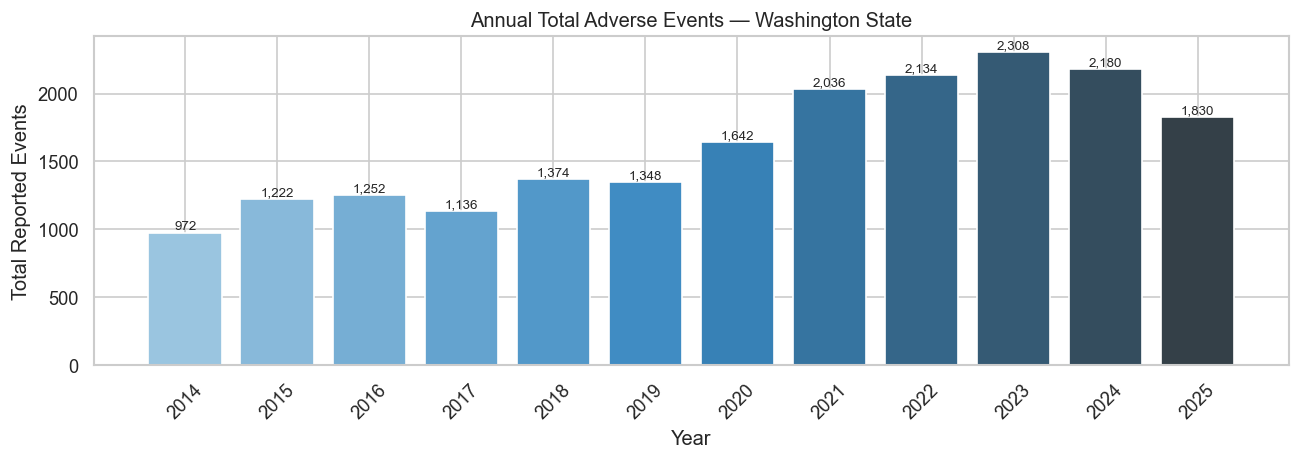

In [4]:
annual = wa.groupby('Year')['Adverse Event Count'].sum().astype(int)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(annual.index.astype(int), annual.values,
              color=sns.color_palette('Blues_d', len(annual)))
for bar, val in zip(bars, annual.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Year')
ax.set_ylabel('Total Reported Events')
ax.set_title('Annual Total Adverse Events — Washington State')
plt.xticks(annual.index.astype(int), rotation=45)
plt.tight_layout()
plt.show()

## 2 · Facility Type Breakdown

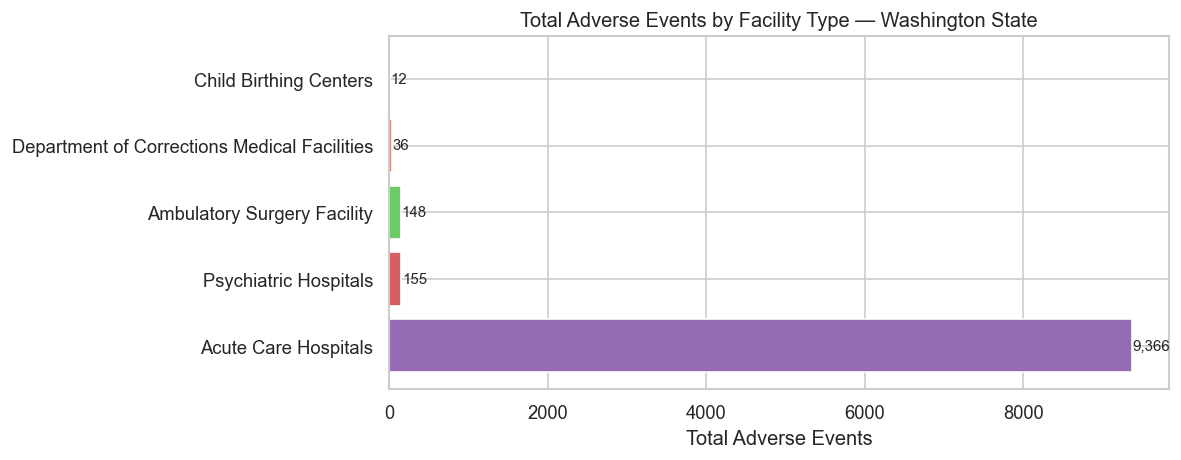

In [5]:
fac_type = wa.groupby('Facility Type')['Adverse Event Count'].sum().astype(int).sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(fac_type.index, fac_type.values,
               color=sns.color_palette('muted', len(fac_type)))
for bar, val in zip(bars, fac_type.values):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Total Adverse Events')
ax.set_title('Total Adverse Events by Facility Type — Washington State')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3 · Event Type Distribution

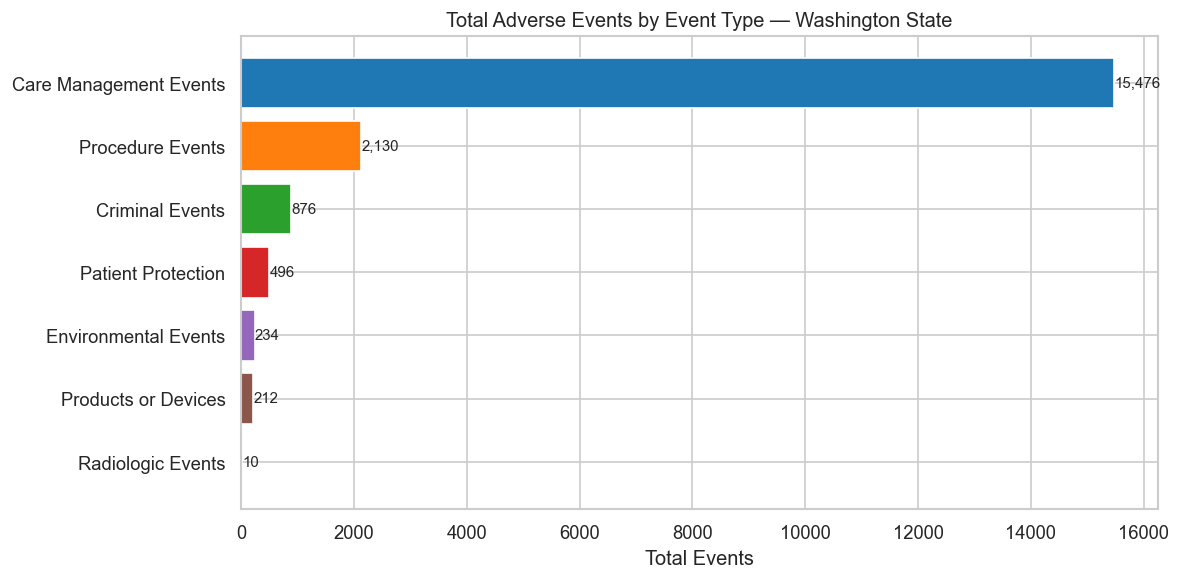

In [6]:
evt_type = wa.groupby('Event Type')['Adverse Event Count'].sum().astype(int).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(evt_type.index, evt_type.values,
               color=sns.color_palette('tab10', len(evt_type)))
for bar, val in zip(bars, evt_type.values):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Total Events')
ax.set_title('Total Adverse Events by Event Type — Washington State')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4 · Top 20 Adverse Events

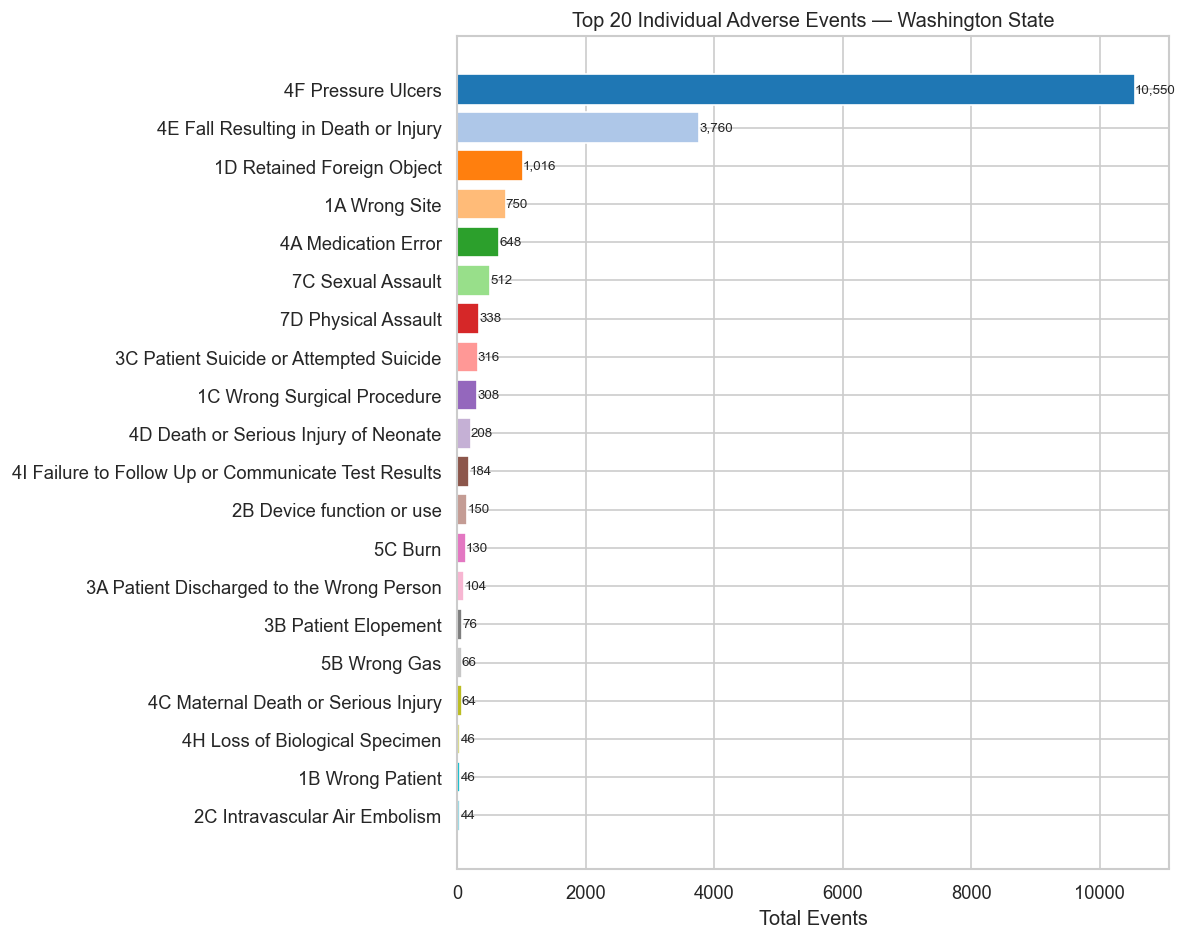

In [7]:
ae = wa.groupby('Adverse Event')['Adverse Event Count'].sum().astype(int).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(ae.index.str[:60], ae.values,
               color=sns.color_palette('tab20', len(ae)))
for bar, val in zip(bars, ae.values):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)
ax.set_xlabel('Total Events')
ax.set_title('Top 20 Individual Adverse Events — Washington State')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5 · Top 15 Counties by Total Adverse Events

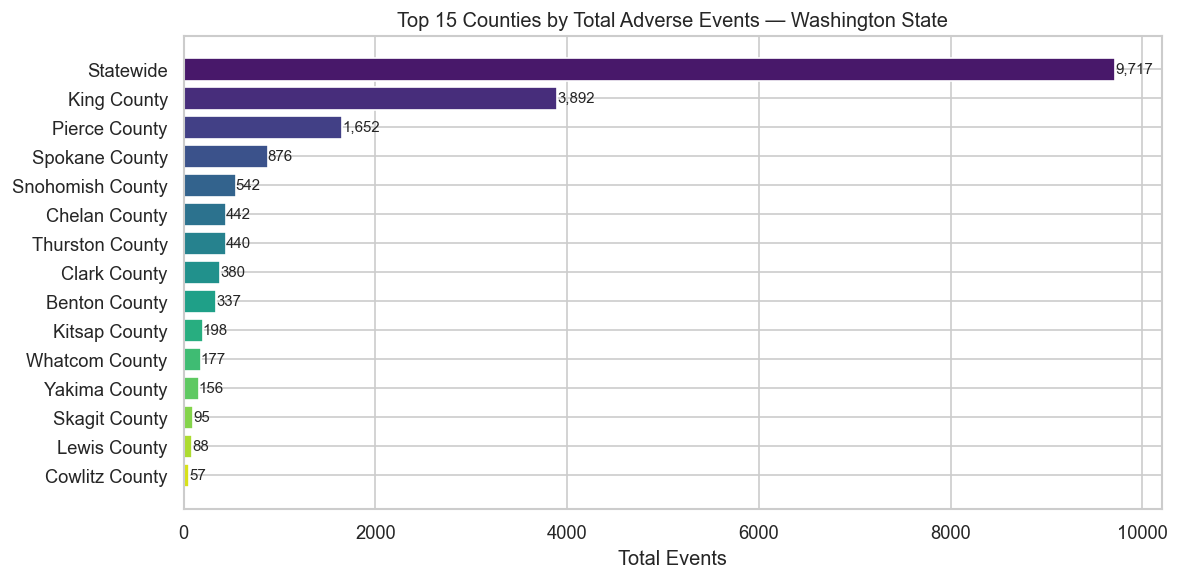

In [8]:
county = wa.groupby('Location')['Adverse Event Count'].sum().astype(int).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(county.index, county.values,
               color=sns.color_palette('viridis', len(county)))
for bar, val in zip(bars, county.values):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Total Events')
ax.set_title('Top 15 Counties by Total Adverse Events — Washington State')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6 · Top 20 Facilities by Total Adverse Events

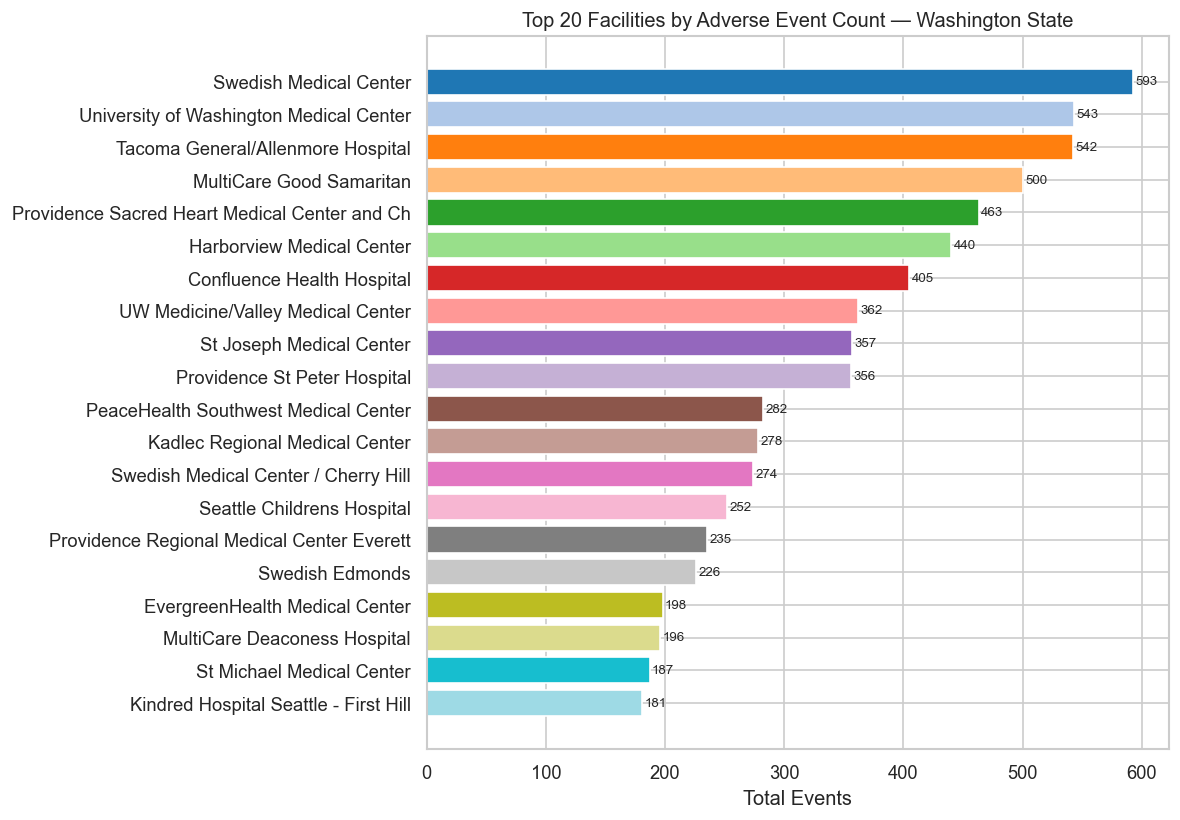

In [9]:
top_fac = (wa.groupby(['Facility Name', 'Facility Type'])['Adverse Event Count']
           .sum().astype(int).reset_index()
           .nlargest(20, 'Adverse Event Count'))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_fac['Facility Name'].str[:45], top_fac['Adverse Event Count'],
               color=sns.color_palette('tab20', 20))
for bar, val in zip(bars, top_fac['Adverse Event Count']):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)
ax.set_xlabel('Total Events')
ax.set_title('Top 20 Facilities by Adverse Event Count — Washington State')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7 · Heatmap: Event Type × Year

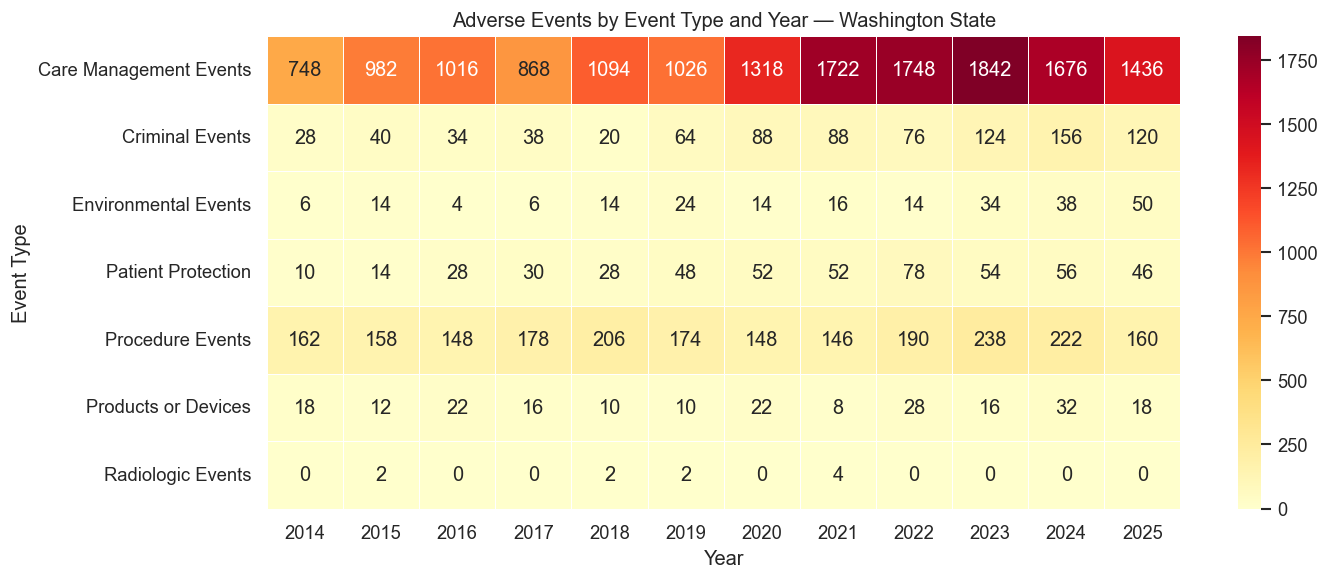

In [10]:
pivot = wa.groupby(['Year', 'Event Type'])['Adverse Event Count'].sum().unstack(fill_value=0).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot.T, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Adverse Events by Event Type and Year — Washington State')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

## 8 · Heatmap: Facility Type × Year

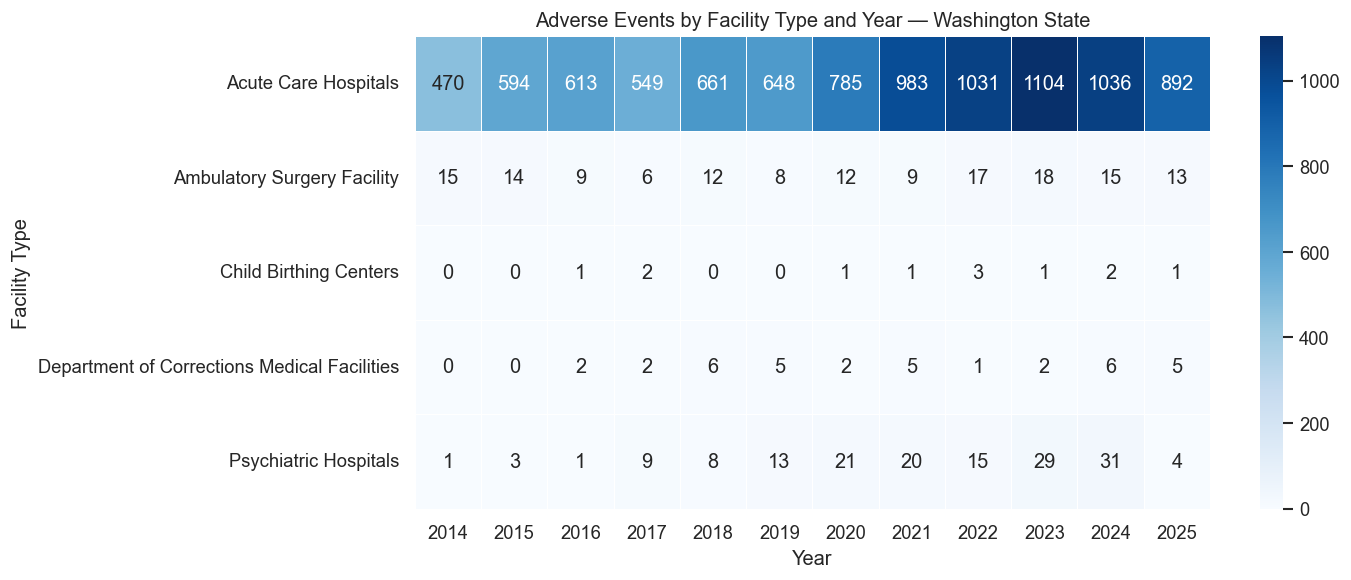

In [11]:
ft_year = wa.groupby(['Year', 'Facility Type'])['Adverse Event Count'].sum().unstack(fill_value=0).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(ft_year.T, annot=True, fmt='d', cmap='Blues', linewidths=0.3, ax=ax)
ax.set_title('Adverse Events by Facility Type and Year — Washington State')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

## 9 · Distribution of Non-Zero Event Counts

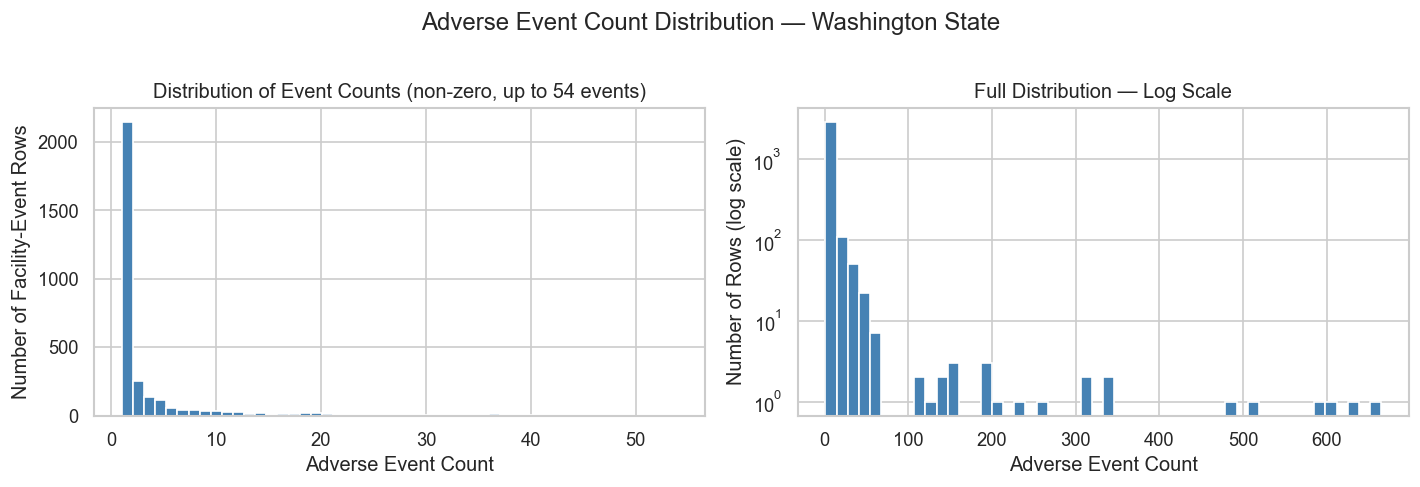

Adverse Event Count — summary (rows with events):
  Total events  : 19,434
  Rows          : 3,128
  Min           : 1
  Median        : 1
  Mean          : 6.2
  Max           : 665

Top 5 highest single-row counts:
Facility Name  Year      Adverse Event  Adverse Event Count
          NaN  2023 4F Pressure Ulcers                665.0
          NaN  2021 4F Pressure Ulcers                628.0
          NaN  2022 4F Pressure Ulcers                608.0
          NaN  2024 4F Pressure Ulcers                586.0
          NaN  2025 4F Pressure Ulcers                514.0


In [12]:
counts = wa_events['Adverse Event Count'].astype(int)
cap = int(counts.sort_values().iloc[int(len(counts) * 0.99)])
counts_trimmed = counts[counts <= cap]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(counts_trimmed, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Adverse Event Count')
axes[0].set_ylabel('Number of Facility-Event Rows')
axes[0].set_title(f'Distribution of Event Counts (non-zero, up to {cap} events)')

axes[1].hist(counts, bins=50, color='steelblue', edgecolor='white', log=True)
axes[1].set_xlabel('Adverse Event Count')
axes[1].set_ylabel('Number of Rows (log scale)')
axes[1].set_title('Full Distribution — Log Scale')

plt.suptitle('Adverse Event Count Distribution — Washington State', y=1.01)
plt.tight_layout()
plt.show()

print('Adverse Event Count — summary (rows with events):')
print(f'  Total events  : {counts.sum():,}')
print(f'  Rows          : {len(counts):,}')
print(f'  Min           : {counts.min()}')
print(f'  Median        : {int(counts.median())}')
print(f'  Mean          : {counts.mean():.1f}')
print(f'  Max           : {counts.max():,}')
print(f'\nTop 5 highest single-row counts:')
print(wa_events.nlargest(5, 'Adverse Event Count')[
    ['Facility Name', 'Year', 'Adverse Event', 'Adverse Event Count']].to_string(index=False))

## 10 · Trend: Top 5 Adverse Events Over Time

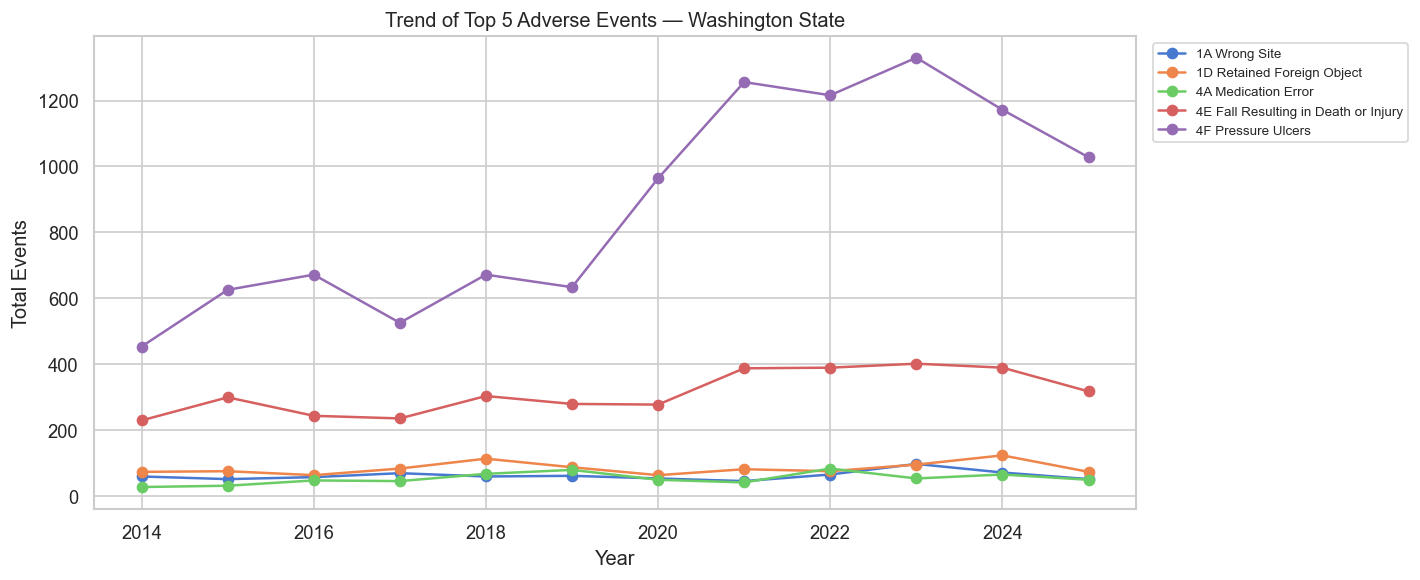

In [13]:
top5_ae = wa.groupby('Adverse Event')['Adverse Event Count'].sum().nlargest(5).index
trend = (wa[wa['Adverse Event'].isin(top5_ae)]
         .groupby(['Year', 'Adverse Event'])['Adverse Event Count'].sum()
         .unstack(fill_value=0).astype(int))

fig, ax = plt.subplots(figsize=(12, 5))
for col in trend.columns:
    ax.plot(trend.index, trend[col], marker='o', label=col[:50])
ax.set_xlabel('Year')
ax.set_ylabel('Total Events')
ax.set_title('Trend of Top 5 Adverse Events — Washington State')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()